In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DAY 3-4 

In [8]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.isnull().sum()


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(17)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# Check duplicate records
df.duplicated().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Verify duplicates removed
df.duplicated().sum()

np.int64(0)

The dataset initially contained 17 duplicate records. These duplicate rows were removed using drop_duplicates(). After cleaning, the dataset contains 0 duplicate records


In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   str    
 1   Segment       9977 non-null   str    
 2   Country       9977 non-null   str    
 3   City          9977 non-null   str    
 4   State         9977 non-null   str    
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   str    
 7   Category      9977 non-null   str    
 8   Sub-Category  9977 non-null   str    
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1.1 MB


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Ship Mode     9977 non-null   category
 1   Segment       9977 non-null   category
 2   Country       9977 non-null   category
 3   City          9977 non-null   category
 4   State         9977 non-null   category
 5   Postal Code   9977 non-null   int64   
 6   Region        9977 non-null   category
 7   Category      9977 non-null   category
 8   Sub-Category  9977 non-null   category
 9   Sales         9977 non-null   float64 
 10  Quantity      9977 non-null   int64   
 11  Discount      9977 non-null   float64 
 12  Profit        9977 non-null   float64 
dtypes: category(8), float64(3), int64(2)
memory usage: 560.3 KB


There were no date columns in the dataset. The categorical text columns were converted from string to category data type for better memory efficiency and analysis. 

In [18]:
df.shape

(6750, 13)

In [19]:
iqr_cols = ["Sales", "Profit"]

for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [20]:
df.to_csv("../data/processed/cleaned_SampleSuperstore.csv", index=False)

In [17]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [15]:
category_cols = [
    "Ship Mode", "Segment", "Country", "City",
    "State", "Region", "Category", "Sub-Category"
]

for col in category_cols:
    df[col] = df[col].astype("category")

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment setup successful!")

Environment setup successful!


In [4]:
df = pd.read_csv("../data/raw/SampleSuperstore.csv")

In [5]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Name": ["Rahul", "Priya", "Aman"],
    "Marks": [85, 90, 78]
})

df

,Name,Marks
0,Rahul,85
1,Priya,90
2,Aman,78


In [ ]:
import os

print(os.getcwd())

c:\Users\gupta\OneDrive\Desktop\apex internship\notebooks


In [ ]:
import os

print(os.path.exists("../data/raw/SampleSuperstore.csv"))


True


In [24]:
with open("../data/raw/SampleSuperstore.csv", "r", encoding="latin1") as f:
    for i in range(5):
        print(f.readline())

In [26]:
import os

file_path = "../data/raw/SampleSuperstore.csv"

print("Exists:", os.path.exists(file_path))
print("Size:", os.path.getsize(file_path), "bytes")

with open(file_path, "rb") as f:
    print("First 100 bytes:", f.read(100))

Exists: True
Size: 0 bytes
First 100 bytes: b''


In [27]:
import os

print(os.getcwd())
print(os.path.getsize("../data/raw/SampleSuperstore.csv"))

c:\Users\gupta\OneDrive\Desktop\apex internship\notebooks
1113007


In [28]:
import pandas as pd

df = pd.read_csv("../data/raw/SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


day (5-6 EDA)

In [21]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,5637.000000,5637.000000,5637.000000,5637.000000,5637.000000
mean,55013.890012,38.736893,3.306546,0.092645,8.989763
std,32857.563784,35.799888,1.859808,0.103167,8.698339
min,1453.000000,0.990000,1.000000,0.000000,-15.476400
25%,22153.000000,12.960000,2.000000,0.000000,3.081400
50%,55044.000000,25.984000,3.000000,0.000000,6.725200
75%,90036.000000,52.990000,4.000000,0.200000,13.572000
max,99301.000000,187.056000,9.000000,0.500000,34.423200


In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 5637 entries, 2 to 9992
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Ship Mode     5637 non-null   category
 1   Segment       5637 non-null   category
 2   Country       5637 non-null   category
 3   City          5637 non-null   category
 4   State         5637 non-null   category
 5   Postal Code   5637 non-null   int64   
 6   Region        5637 non-null   category
 7   Category      5637 non-null   category
 8   Sub-Category  5637 non-null   category
 9   Sales         5637 non-null   float64 
 10  Quantity      5637 non-null   int64   
 11  Discount      5637 non-null   float64 
 12  Profit        5637 non-null   float64 
dtypes: category(8), float64(3), int64(2)
memory usage: 318.7 KB


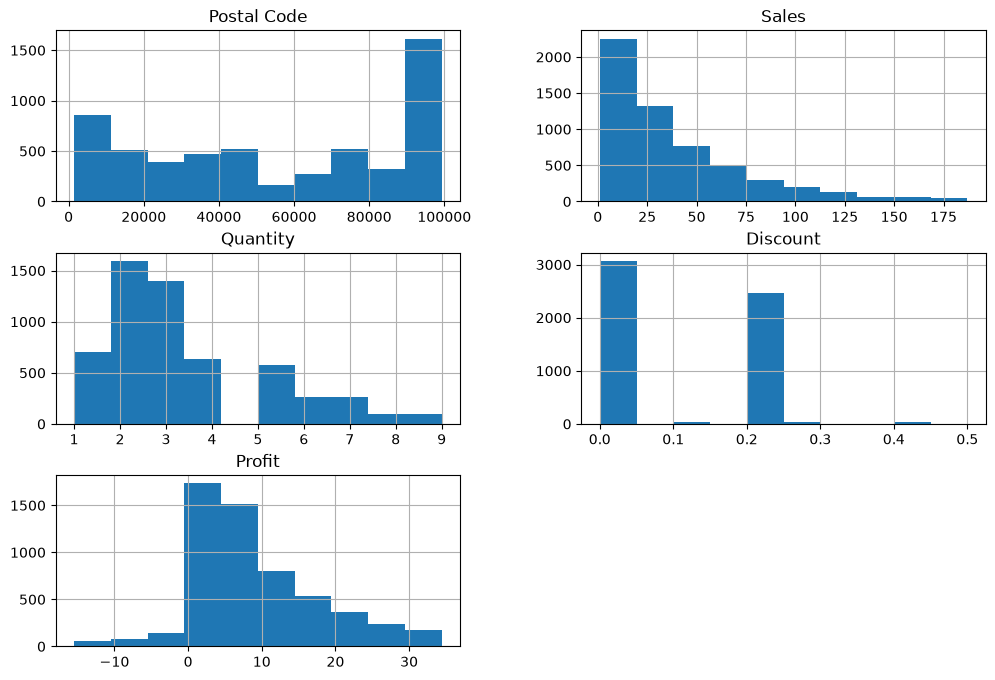

In [23]:
df.hist(figsize=(12,8))
plt.show()

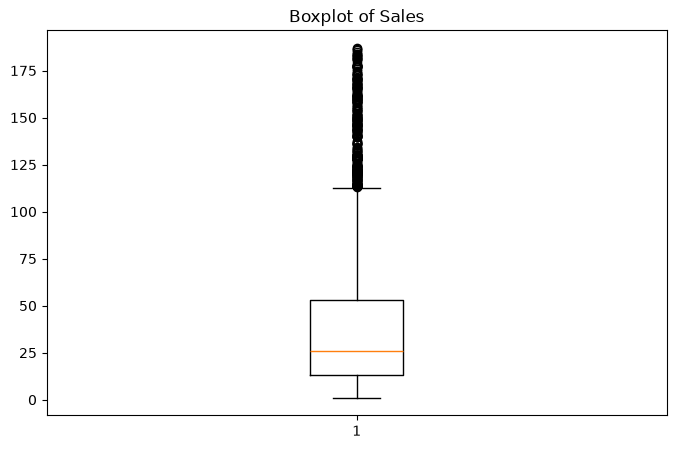

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["Sales"])
plt.title("Boxplot of Sales")
plt.show()

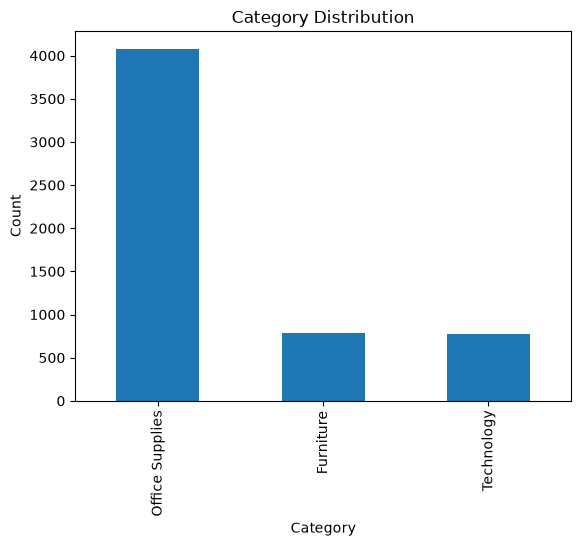

In [25]:
df["Category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

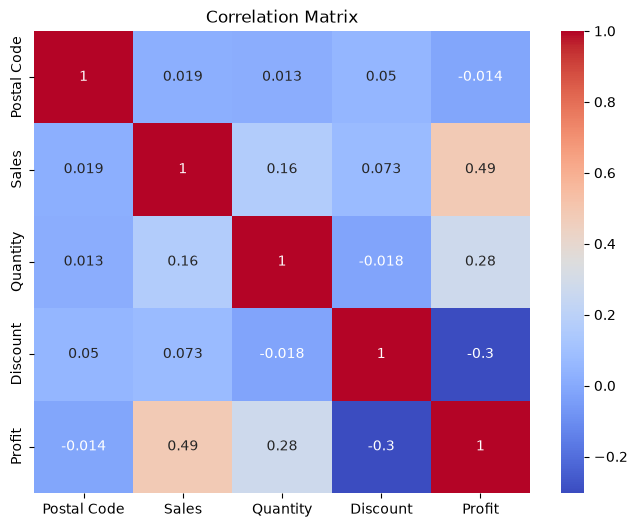

In [26]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

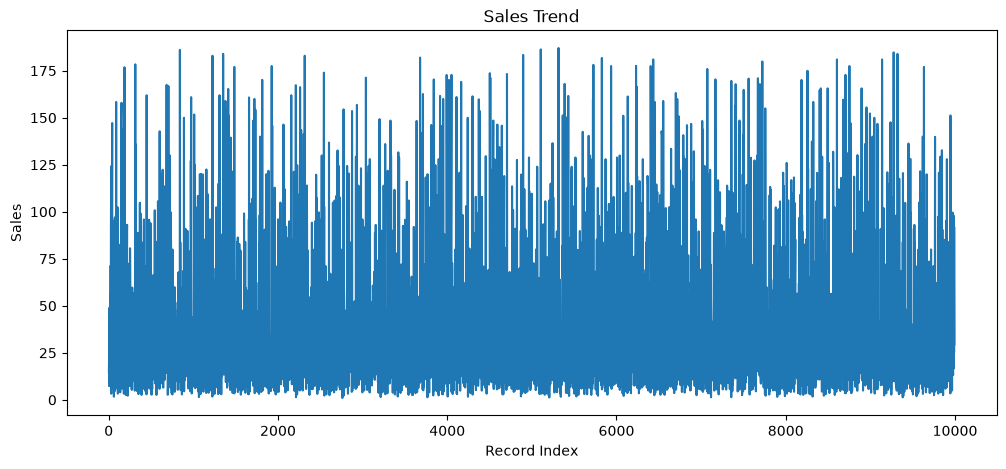

In [27]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Sales"])
plt.title("Sales Trend")
plt.xlabel("Record Index")
plt.ylabel("Sales")
plt.show()

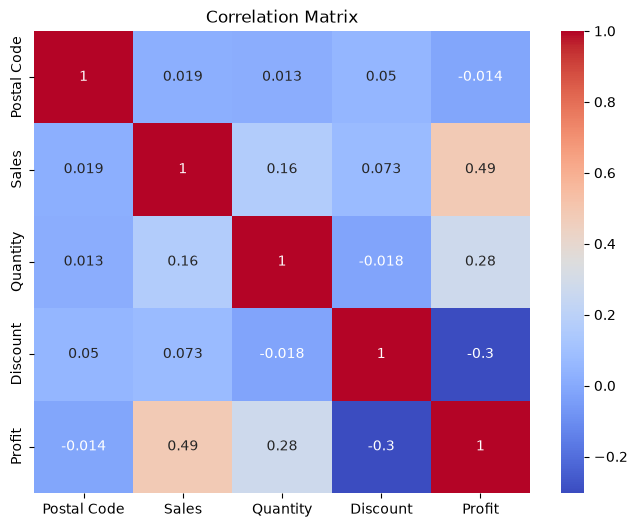

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Key Insights
The dataset contains 9,994 records with no missing values, ensuring good data quality.

A total of 17 duplicate records were identified and removed during data cleaning.

Most sales transactions have relatively low sales values, while only a few transactions have very high sales, indicating a right-skewed distribution.

Office Supplies is the most frequently purchased category compared to Furniture and Technology.

The correlation matrix shows that Sales and Profit have a moderate positive relationship (0.49), while Discount and Profit have a negative relationship (-0.30), suggesting that higher discounts tend to reduce profit.